In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (LabelEncoder, OrdinalEncoder, StandardScaler, RobustScaler)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import (
    StratifiedKFold, cross_val_predict, cross_validate
)
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, classification_report
)
from scipy.stats import ks_2samp

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed. Run: pip install shap')


import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

In [2]:
from google.colab import drive
drive.mount('datasets',force_remount=True)

Mounted at datasets


In [4]:
# from google.colab import drive
# drive.mount('datasets/MyDrive',force_remount=True)

clients = pd.read_csv(
    './datasets/MyDrive/TOOL_CLIENT.csv',
    dtype={'CLIENT_ID': str}
)

sales = pd.read_csv(
    'datasets/MyDrive/TOOL_SALES.csv',
    dtype={'CLIENT_ID': str, 'ITEM_ID': str, 'CANCELLED': str},
    low_memory=False
)

initial_number_of_sales = len(sales)
initial_number_of_clients = len(clients)

print(f'Sales  : {sales.shape[0]:,} rows × {sales.shape[1]} cols')
print(f'Clients: {clients.shape[0]:,} rows × {clients.shape[1]} cols')

Sales  : 2,050,449 rows × 10 cols
Clients: 93,257 rows × 8 cols


data cleaning and types checking 

In [5]:
clients["CLIENT_CREATE DATE"] = pd.to_datetime(clients["CLIENT_CREATE DATE"])
clients["REGION"]             = clients["REGION"].astype("string")
clients["REGION"]             = clients["REGION"].fillna("unknown")
clients["REGION"]             = clients["REGION"].astype("string")
clients["ECO_POT_CLASS"]      = clients["ECO_POT_CLASS"].astype("string")
clients["RISK_CAT"]           = clients["RISK_CAT"].astype("string")
sales["UNIT"]                 = sales["UNIT"].astype("string")
sales["FAMILY_CODE"]          = sales["FAMILY_CODE"].astype("string")
sales["YYYYMM"]               = pd.to_datetime(sales["YYYYMM"], format="%Y%m")
sales["SALES_CHANNEL"]        = sales["SALES_CHANNEL"].astype("string")
sales['CANCELLED']            = (sales['CANCELLED'] == 'X').astype(int)


## Inspecting transactions

**Anomalies in transactions:**
- `negative values: ` are not those of primary interest but could provide usefull informations, these transactions signal product returns from clients. NNET
- `"0" value: ` are not those of primary interest but could provide usefull, these transactions signal ... 0NET

So we save these informations in other columns to build features later.

In [6]:
sales.loc[sales['NET'] < 0, 'NNET'] = sales['NET']
sales.loc[sales['NET'] == 0, '0NET'] = sales['NET']
sales['NNET'] = sales['NNET'].where(sales['NNET'] < 0, np.nan)  #NeW COLUMN!
sales['0NET'] = sales['0NET'].where(sales['0NET'] == 0, np.nan)  #NeW COLUMN!
sales['NET'] = sales['NET'].where(sales['NET'] > 0, np.nan) 

transactions_with_negative_values = len(sales[sales['NNET'] < 0])
transactions_with_0_value = len(sales[sales['0NET'] == 0])



Standalone transactions are not usefull. So, we remove these transactions.

In [7]:
df_unique = sales[~sales["CLIENT_ID"].duplicated(keep=False)]
standalone_transactions = len(df_unique)
clients_who_made_1_transaction = set(df_unique["CLIENT_ID"])
sales = sales[~sales['CLIENT_ID'].isin(clients_who_made_1_transaction)]
clients = clients[~clients['CLIENT_ID'].isin(clients_who_made_1_transaction)]
print(len(sales))
print(len(clients))

2037299
80107


More about standalone transactions: we also should remove clients who made more than one transaction, BUT on a single day, and then disappeared. 

In [8]:
daily_counts = (
    sales.groupby(['CLIENT_ID', 'YYYYMM'])
    .size()
    .reset_index(name='n_days_purchase')
)
daily_counts

days_per_client = (
    sales.groupby('CLIENT_ID')['YYYYMM']
    .nunique()
    .reset_index(name='n_days')
)

multi_same_day = (
    daily_counts.groupby('CLIENT_ID')['n_days_purchase']
    .max()
    .reset_index(name='max_same_day_purchases')
)
# print(days_per_client)
# print(multi_same_day)
single_day_purchase_clients = (
    days_per_client.merge(multi_same_day, on='CLIENT_ID')
)


single_day_purchase_clients = single_day_purchase_clients[
    (single_day_purchase_clients['n_days'] == 1) &
    (single_day_purchase_clients['max_same_day_purchases'] > 1)
]['CLIENT_ID']


multiple_1day_purchase_transactions = sales[sales['CLIENT_ID'].isin(single_day_purchase_clients)]
sales = sales[~sales['CLIENT_ID'].isin(single_day_purchase_clients)]

clients = clients[~clients['CLIENT_ID'].isin(single_day_purchase_clients)]

Creating additional columns to separate month and year

In [9]:
# YYYYMM → year / month columns for easy filtering
sales['YYYYMM'] = sales['YYYYMM'].astype(str).str.zfill(0)  # safety pad
sales['year']   = sales['YYYYMM'].str[:4].astype(int)
sales['month']  = sales['YYYYMM'].str[5:7].astype(int)

# Visualizing transactions 

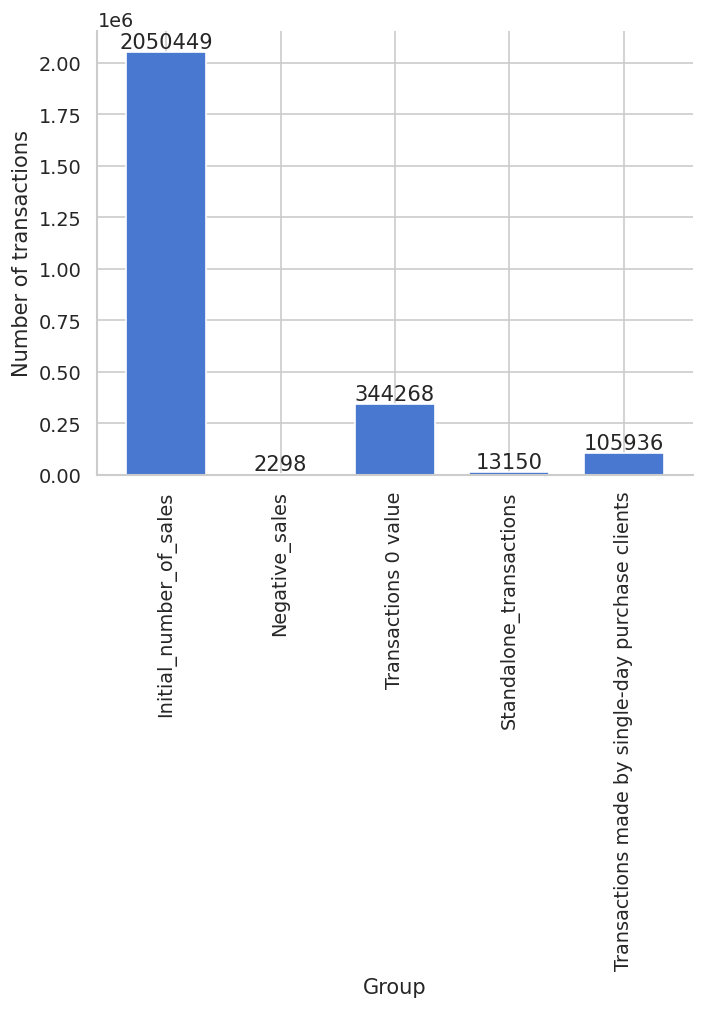

In [10]:
import matplotlib.pyplot as plt

visualize_transactions = pd.Series({
    "Initial_number_of_sales": initial_number_of_sales,
    "Negative_sales": transactions_with_negative_values,
    "Transactions 0 value": transactions_with_0_value,
    "Standalone_transactions": standalone_transactions,
    "Transactions made by single-day purchase clients": len(multiple_1day_purchase_transactions)
})

ax = visualize_transactions.plot(kind='bar', width=0.7)


for i, v in enumerate(visualize_transactions.values):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.xlabel('Group')
plt.ylabel('Number of transactions')
plt.show()

In [11]:
to_display = pd.DataFrame([
    {
        "Transactions with negative values:": transactions_with_negative_values,
        "Transactions with 0 value:": transactions_with_0_value,
        "Total N° transactions": initial_number_of_sales,
        "Percentage": (transactions_with_negative_values+transactions_with_0_value) / initial_number_of_sales * 100
    }])
to_display1 = pd.DataFrame([
    {
        "N° of clints of \"standalone\" transactions:": len(clients_who_made_1_transaction),
        "Total N° of clients": initial_number_of_clients,
        "Percentage": len(clients_who_made_1_transaction) / initial_number_of_sales*100,
    }])
to_display2 = pd.DataFrame([
    {
        "N° of single-day-purchase clients:": len(single_day_purchase_clients),
        "Total N° of clients": initial_number_of_clients,
        "Percentage": len(single_day_purchase_clients)/ initial_number_of_clients*100,
    }
    
])

display(to_display)
display(to_display1)
display(to_display2)

,Transactions with negative values:,Transactions with 0 value:,Total N° transactions,Percentage
0,2298,344268,2050449,16.901957


,"N° of clints of ""standalone"" transactions:",Total N° of clients,Percentage
0,13150,93257,0.641323


,N° of single-day-purchase clients:,Total N° of clients,Percentage
0,20893,93257,22.40368


# Dates

This part is critical, and yet to be defined.
In this notebook we consider these time windows:

|----------2017---------|------2018------|--------2019-------|----2020-----|-----2021-----|

|-feature time window-|------observing inactivity window--|----come-back window-----|

|----------2017---------|------2018------|--------2019-------|----2020-----|-----2021-----|

|-......feature time window--------------|--churn windows--|----come-back window-----|

In [16]:
# ── Define the three time windows ─────────────────────────────────────────────
obs_sales    = sales[sales['year'].isin([2017, 2018])].copy()  # feature window
gap_sales    = sales[sales['year'] == 2019].copy()              # silence gap
future_sales = sales[sales['year'].isin([2020, 2021])].copy()  # target window

# ── Churn universe ────────────────────────────────────────────────────────────
# Clients who bought in 2017-2018 but NOT in 2019
buyers_obs    = set(obs_sales['CLIENT_ID'].unique())
buyers_gap    = set(gap_sales['CLIENT_ID'].unique())
churned_ids   = buyers_obs - buyers_gap

# ── Target variable ───────────────────────────────────────────────────────────
# 1 = reactivated in 2020-2021, 0 = still dormant
buyers_future = set(future_sales['CLIENT_ID'].unique())

clients_churn = clients[clients['CLIENT_ID'].isin(churned_ids)]
clients_churn = clients_churn.sort_values('CLIENT_ID', ascending=True)

target_series = pd.Series({cid: int(cid in buyers_future) for cid in churned_ids},name='target').sort_index(ascending=True)


print(f'Observation buyers (2017-2018)   : {len(buyers_obs):>6,}')
print(f'Clients who also bought in 2019  : {len(buyers_obs & buyers_gap):>6,}')
print(f'Churned (no purchase in 2019)    : {len(churned_ids):>6,}')
print(f'  └─ Reactivated (target=1)      : {target_series.sum():>6,}  ({target_series.mean()*100:.1f}%)')
print(f'  └─ Remained dormant (target=0) : {(1-target_series).sum():>6,}  ({(1-target_series.mean())*100:.1f}%)')

Observation buyers (2017-2018)   : 48,734
Clients who also bought in 2019  : 29,808
Churned (no purchase in 2019)    : 18,926
  └─ Reactivated (target=1)      :  9,425  (49.8%)
  └─ Remained dormant (target=0) :  9,501  (50.2%)


Feature engineering

In [20]:

churn_client_sales = obs_sales[obs_sales['CLIENT_ID'].isin(churned_ids)].copy()

tool_spend  = churn_client_sales[churn_client_sales['FLG_TOOL']==1].groupby('CLIENT_ID')['NET'].sum().rename('tool_spend')
total_spend = churn_client_sales.groupby('CLIENT_ID')['NET'].sum().rename('total_spend')
tool_ratio  = (tool_spend / total_spend).fillna(0).rename('tool_ratio')


model                = clients_churn[['CLIENT_ID']].copy()
print(model)
final_clients_churn  = clients_churn[['CLIENT_ID']].copy()
total_amount_spent   = churn_client_sales.groupby('CLIENT_ID')['NET'].sum()
average_amount_spent = churn_client_sales.groupby('CLIENT_ID')['NET'].mean()
max_amount_spent     = churn_client_sales.groupby('CLIENT_ID')['NET'].max()
std_amount_spent     = churn_client_sales.groupby('CLIENT_ID')['NET'].std().fillna(0)
freq_n_transactions  = churn_client_sales.groupby('CLIENT_ID')['NET'].count()
n_distinct_channels  = churn_client_sales.groupby('CLIENT_ID')['SALES_CHANNEL'].nunique()
main_channel         = churn_client_sales.groupby('CLIENT_ID')['SALES_CHANNEL'].agg(lambda x: x.mode().iloc[0])
n_product_families   = churn_client_sales.groupby('CLIENT_ID')['FAMILY_CODE'].nunique()
n_product_groups     = churn_client_sales.groupby('CLIENT_ID')['GROUP_CODE'].nunique()
n_canc               = churn_client_sales.groupby('CLIENT_ID')['CANCELLED'].count()
n_neg_tranx          = churn_client_sales.groupby('CLIENT_ID')['NNET'].count()
n_zero_tranx         = churn_client_sales.groupby('CLIENT_ID')['0NET'].count()

model['freq_n_transactions']    = model['CLIENT_ID'].map(freq_n_transactions)
model['total_amount_spent']     = model['CLIENT_ID'].map(total_amount_spent)
model['average_amount_spent']   = model['CLIENT_ID'].map(average_amount_spent)
model['max_amount_spent']       = model['CLIENT_ID'].map(max_amount_spent)
model['std_amount_spent']       = model['CLIENT_ID'].map(std_amount_spent)
model['n_distinct_channels']    = model['CLIENT_ID'].map(n_distinct_channels)
model['main_channel']           = model['CLIENT_ID'].map(main_channel)
model['n_product_families']     = model['CLIENT_ID'].map(n_product_families)
model['n_product_groups']       = model['CLIENT_ID'].map(n_product_groups)
model['n_canc']                 = model['CLIENT_ID'].map(n_canc)
model['tool_ratio']             = model['CLIENT_ID'].map(tool_ratio)
model['n_neg_tranx']            = model['CLIENT_ID'].map(n_neg_tranx)
model['n_zero_tranx']           = model['CLIENT_ID'].map(n_zero_tranx)

#features taken from clients dataframe
model['REGION']        = clients_churn["REGION"] 
model['N_EMPLOYEES']   = clients_churn["N_EMPLOYEES"] 
model['ECONOMIC_POT']  = clients_churn["ECONOMIC_POT"] 
model['TRADE_SECTOR']  = clients_churn["TRADE SECTOR"] 
model['RISK_CAT']      = clients_churn["RISK_CAT"] 
model['ECO_POT_CLASS'] = clients_churn["ECO_POT_CLASS"] 
model['tool_ratio']    = model['tool_ratio'].replace([np.inf, -np.inf], np.nan)

model = model.sort_values('CLIENT_ID', ascending=True)
y = target_series


model = model.drop(columns=['CLIENT_ID'])
# y = y.to_numpy().reshape(-1, 1)

# clients = clients.merge(total_amount_spent.reset_index(), left_on='CLIENT_ID', right_on='CLIENT_ID', how='left')

      CLIENT_ID
12166  00000002
5945   00000011
13196  00000012
860    00000018
11993  00000034
...         ...
78353  00078359
78356  00078371
78405  00078408
78424  00078419
78428  00078422

[18926 rows x 1 columns]


In [21]:
# ── Build the pre-processing ColumnTransformer ────────────────────────────────
CATEGORICAL_FEATURES = ['ECO_POT_CLASS','RISK_CAT','main_channel','REGION','TRADE_SECTOR']

# columns with numeric data: int64 and float64
NUMERIC_FEATURES = ['freq_n_transactions','total_amount_spent','average_amount_spent','max_amount_spent','std_amount_spent','n_distinct_channels','n_product_families','n_product_groups','n_canc','tool_ratio','n_neg_tranx','n_zero_tranx','N_EMPLOYEES','ECONOMIC_POT','tool_ratio']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    # RobustScaler uses IQR instead of std dev → less sensitive to outliers in spend data
    ('scaler',  RobustScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer,     NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
    # ('bin', 'passthrough',           BINARY_FEATURES)
])

# ── Feature names after transformation ────────────────────────────────────────
# (useful for feature importance plots later)
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES #+ BINARY_FEATURES

print('Preprocessor built.')
print(f'Total features in: {len(ALL_FEATURES)}')

Preprocessor built.
Total features in: 20


---
## 5. Model training & cross-validation

### Model selection rationale

| Model | Pros | Cons |
|---|---|---|
| Logistic Regression | Interpretable, fast, good baseline | Linear decision boundary, assumes feature independence |
| Random Forest | Handles non-linearity, robust to outliers | Less interpretable, can overfit noisy features |
| Gradient Boosting | Best accuracy on tabular data, handles feature interactions | Slower to train, more hyperparameters |
| Light Gmb  | Bababababa | Bababababa|
| XGBoost | Bababababa| Bababababa|

### Evaluation methodology
We use **5-fold stratified cross-validation** with `cross_val_predict` to get out-of-fold probability scores for the full dataset. This gives us an unbiased estimate of model performance without holding out a separate test set (important when the dataset is not enormous).

### Primary metrics
- **AUC-ROC**: measures the model's ability to rank positives above negatives — the most important metric for a propensity model
- **KS statistic**: the maximum separation between the CDF of scores for positives and negatives
- **Lift**: at a given percentile, how many more positives do we capture vs random selection?

Test whether logistic regression beats simple heuristics such as:

months since last purchase
historical purchase count
historical spend
tenure
average interpurchase gap

In [23]:
# ── Define boosted candidate models ─────────────────────────────────────────
RANDOM_STATE = 42

# useful for XGB on imbalanced data
# scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'Logistic Regression': Pipeline([
        ('prep', preprocessor),
        ('model', LogisticRegression(
            C=1.0,                   # less regularization than 0.1
            max_iter=5000,
            # class_weight='balanced',
            solver='lbfgs',
            random_state=RANDOM_STATE
        ))
    ]),

    'Random Forest': Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=500,        # more trees
            max_depth=15,            # deeper trees
            min_samples_leaf=10,     # less restrictive than 20
            class_weight='balanced',
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]),

    'Gradient Boosting': Pipeline([
        ('prep', preprocessor),
        ('model', GradientBoostingClassifier(
            n_estimators=500,        # more boosting rounds
            learning_rate=0.03,      # smaller LR, more stable with more trees
            max_depth=5,
            min_samples_leaf=10,
            subsample=0.8,
            random_state=RANDOM_STATE
        ))
    ]),
    'Gradient Boosting2': Pipeline([
        ('prep',  preprocessor),
        ('model', GradientBoostingClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            min_samples_leaf=20,
            subsample=0.8,           # stochastic GBM: reduces overfitting
            random_state=RANDOM_STATE
        ))
    ]),

    'LGBM': Pipeline(steps=[
        ("prep", preprocessor),
        ("model", LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=12,
            min_child_samples=10,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight='balanced',
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]),

    'XGB': Pipeline(steps=[
        ("prep", preprocessor),
        ("model", XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,             # 10 is often too aggressive
            min_child_weight=5,      # less restrictive than 20
            subsample=0.8,
            colsample_bytree=0.8,
            # scale_pos_weight=scale_pos_weight,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            eval_metric='logloss'
        ))
    ])
}

print('Boosted models configured.')

Boosted models configured.


In [24]:



# first split: train vs temp
X_train, X_val, y_train, y_val = train_test_split(
    model, y, test_size=0.30, shuffle=False
)

# second split: validation vs test
X_valid, X_test, y_valid, y_test = train_test_split(
    X_val, y_val, test_size=0.50, shuffle=False
)

In [25]:
results = {}
fitted_models = {}

for name, pipeline in models.items():
    print(f"Training {name}...")

    # fit on TRAIN only
    pipeline.fit(X_train, y_train)

    # score on VALID only
    valid_probs = pipeline.predict_proba(X_valid)[:, 1]
    print("valid_probs shape:", valid_probs.shape)

    auc = roc_auc_score(y_valid, valid_probs)
    ap  = average_precision_score(y_valid, valid_probs)

    pos = valid_probs[y_valid == 1]
    neg = valid_probs[y_valid == 0]
    ks  = ks_2samp(pos, neg).statistic

    results[name] = {
        "probs_valid": valid_probs,
        "auc_valid": auc,
        "ap_valid": ap,
        "ks_valid": ks
    }
    fitted_models[name] = pipeline

    print(f"  VALID AUC = {auc:.4f}  |  Avg Precision = {ap:.4f}  |  KS = {ks:.4f}")

print()

results_df = (
    pd.DataFrame(results)
    .T
    .sort_values(["auc_valid", "ap_valid", "ks_valid"], ascending=False)
)

print(results_df)

best_model_name = results_df.index[0]
best_model = fitted_models[best_model_name]

print()
print(f'Best model on VALID: {best_model_name}  (AUC {results[best_model_name]["auc_valid"]:.4f})')

# -----------------------------
# Final evaluation on TEST
# -----------------------------
test_probs = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, test_probs)
test_ap  = average_precision_score(y_test, test_probs)

test_pos = test_probs[y_test == 1]
test_neg = test_probs[y_test == 0]
test_ks  = ks_2samp(test_pos, test_neg).statistic

print()
print("Final TEST performance")
print(f"  AUC = {test_auc:.4f}  |  Avg Precision = {test_ap:.4f}  |  KS = {test_ks:.4f}")

Training Logistic Regression...
valid_probs shape: (2839,)
  VALID AUC = 0.7959  |  Avg Precision = 0.7999  |  KS = 0.4870
Training Random Forest...
valid_probs shape: (2839,)
  VALID AUC = 0.8472  |  Avg Precision = 0.8526  |  KS = 0.5795
Training Gradient Boosting...
valid_probs shape: (2839,)
  VALID AUC = 0.8477  |  Avg Precision = 0.8555  |  KS = 0.5861
Training Gradient Boosting2...
valid_probs shape: (2839,)
  VALID AUC = 0.8500  |  Avg Precision = 0.8565  |  KS = 0.5844
Training LGBM...
[LightGBM] [Info] Number of positive: 6824, number of negative: 6424
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002380 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2366
[LightGBM] [Info] Number of data points in the train set: 13248, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
valid_pr

---
## 6. Evaluation

We evaluate the model across four dimensions:
1. **ROC curve** — visualises the AUC and compares models
2. **Score distribution** — separability between positives and negatives
3. **Decile lift table** — shows the targeting efficiency at every cut-off
4. **KS plot** — shows the maximum separation between cumulative distributions

KeyError: 'probs'

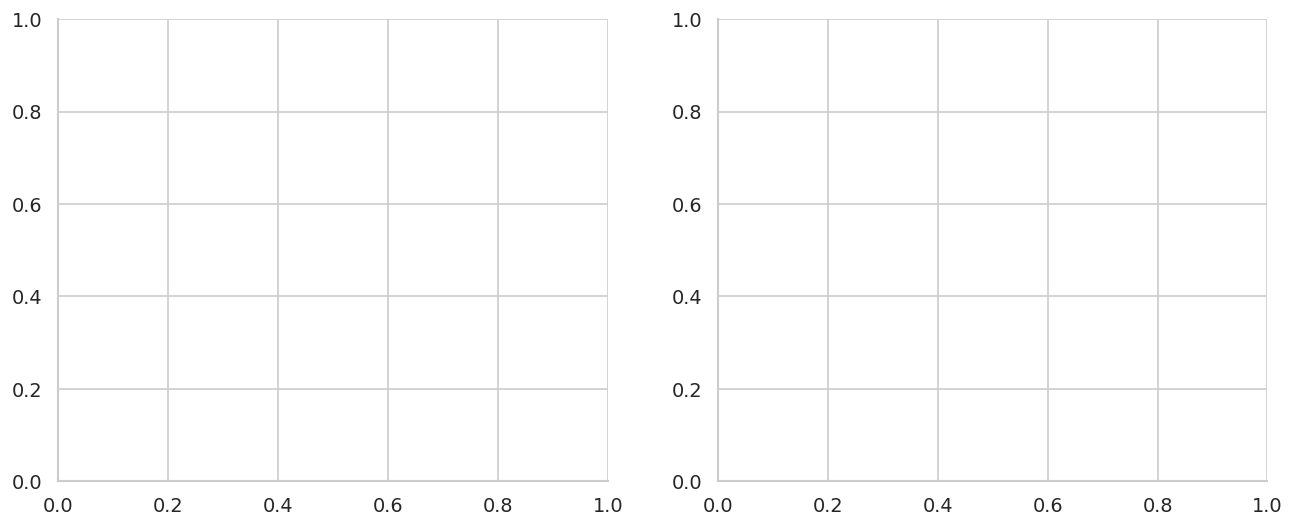

In [26]:
# ── ROC curves ────────────────────────────────────────────────────────────────
colors = ['#378ADD', '#5DCAA5', '#E85D24']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: ROC curves
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y, res['probs'])
    axes[0].plot(fpr, tpr, label=f"{name}  AUC={res['auc']:.3f}", color=color, linewidth=2)
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.4, label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC curves — 5-fold OOF')
axes[0].legend(fontsize=9)
axes[0].set_aspect('equal')

# Right: Score distribution for best model
best_probs = results[best_model_name]['probs']
axes[1].hist(best_probs[y==0], bins=40, alpha=0.6, color='#B4B2A9',label='Not reactivated', density=True)
axes[1].hist(best_probs[y==1], bins=40, alpha=0.6, color='#378ADD',label='Reactivated', density=True)
axes[1].set_xlabel('Predicted reactivation probability')
axes[1].set_ylabel('Density')
axes[1].set_title(f'Score distribution — {best_model_name}')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

── Decile lift table ─────────────────────────────────────────────────────────
Sort clients by score descending. Divide into 10 equal buckets (deciles).
For each decile compute:
  - Reactivation rate (% of actual positives in that bucket)
  - Cumulative reactivation rate (captures how fast we 'collect' all positives)
  - Lift = decile_rate / baseline_rate

In [ ]:
baseline_rate = y.mean()

lift_df = pd.DataFrame({
    'score' : best_probs,
    'target': y.values
}).sort_values('score', ascending=False).reset_index(drop=True)

lift_df['decile'] = pd.qcut(lift_df.index, q=10, labels=range(1, 11))

decile_table = (
    lift_df.groupby('decile', observed=False)
    .agg(
        n_clients  = ('target', 'count'),
        n_positive = ('target', 'sum'),
        react_rate = ('target', 'mean')
    )
    .assign(
        lift = lambda d: d['react_rate'] / baseline_rate,
        cum_positive = lambda d: d['n_positive'].cumsum(),
        cum_rate     = lambda d: d['n_positive'].cumsum() / y.sum()
    )
)

print('Decile lift table:')
dec_table = decile_table[['n_clients','n_positive','react_rate','lift','cum_rate']].style.format({'react_rate': '{:.1%}', 'lift': '{:.2f}x', 'cum_rate': '{:.1%}'}).bar(subset='lift', color='#378ADD')
dec_table

Decile lift table:


,n_clients,n_positive,react_rate,lift,cum_rate
decile,,,,,
1,1893,1602,84.6%,1.70x,17.0%
2,1893,1475,77.9%,1.56x,32.6%
3,1892,1368,72.3%,1.45x,47.2%
4,1893,1177,62.2%,1.25x,59.6%
5,1892,1048,55.4%,1.11x,70.8%
6,1893,876,46.3%,0.93x,80.1%
7,1892,732,38.7%,0.78x,87.8%
8,1893,560,29.6%,0.59x,93.8%
9,1892,393,20.8%,0.42x,97.9%


: 

This is a decile lift table, commonly used to evaluate how well a predictive model (usually for classification) ranks cases from most likely to least likely positive.

What “deciles” mean
The dataset is sorted by the model’s predicted score (highest → lowest).
Then it’s split into 10 equal-sized groups (deciles).
Decile 1 = top 10% (most likely positives)
Decile 10 = bottom 10% (least likely positives)

Column-by-column explanation
n_clients
Number of samples in each decile
Roughly equal across rows (~1890 each)

n_positive
Number of actual positive cases in that decile
Example:
Decile 1 → 1602 positives (very high)
Decile 10 → 194 positives (very low)

👉 This already shows the model is ranking well (positives concentrated at the top).

react_rate
Percentage of positives in that decile
Formula:
react_rate = n_positive / n_clients
Example:
Decile 1 → 84.6%
Decile 10 → 10.2%
👉 Higher at the top = good model separation.


lift
Measures how much better this decile is compared to the overall average
Formula:
lift = (decile react_rate) / (overall react_rate)
Interpretation:
1.0x = average
>1.0x = better than average
<1.0x = worse than average
Example:
Decile 1 → 1.70x
→ 70% better than random targeting
Decile 10 → 0.21x
→ very poor (as expected for lowest scores)


cum_rate (cumulative rate)
% of all positives captured up to that decile
Example:
Top 10% (Decile 1) → captures 17.0% of all positives
Top 20% → 32.6%
Top 50% → 70.8%
Top 100% → 100%
👉 This tells you how quickly you capture positives as you go down the ranked list.

Business insight (very important)
You can decide how much of the population to target.
Examples:
Target top 10% → get 17% of all positives
Target top 30% → get 47.2% of positives
Target top 50% → get 70.8% of positives


The model ranks customers effectively:
Positives are heavily concentrated in early deciles
Lift > 1 in top deciles confirms strong predictive power
You can use this table to choose an optimal cutoff based on cost vs benefit





Lift and cumulative gain charts. These show how well your model ranks customers and how useful it is for targeting.

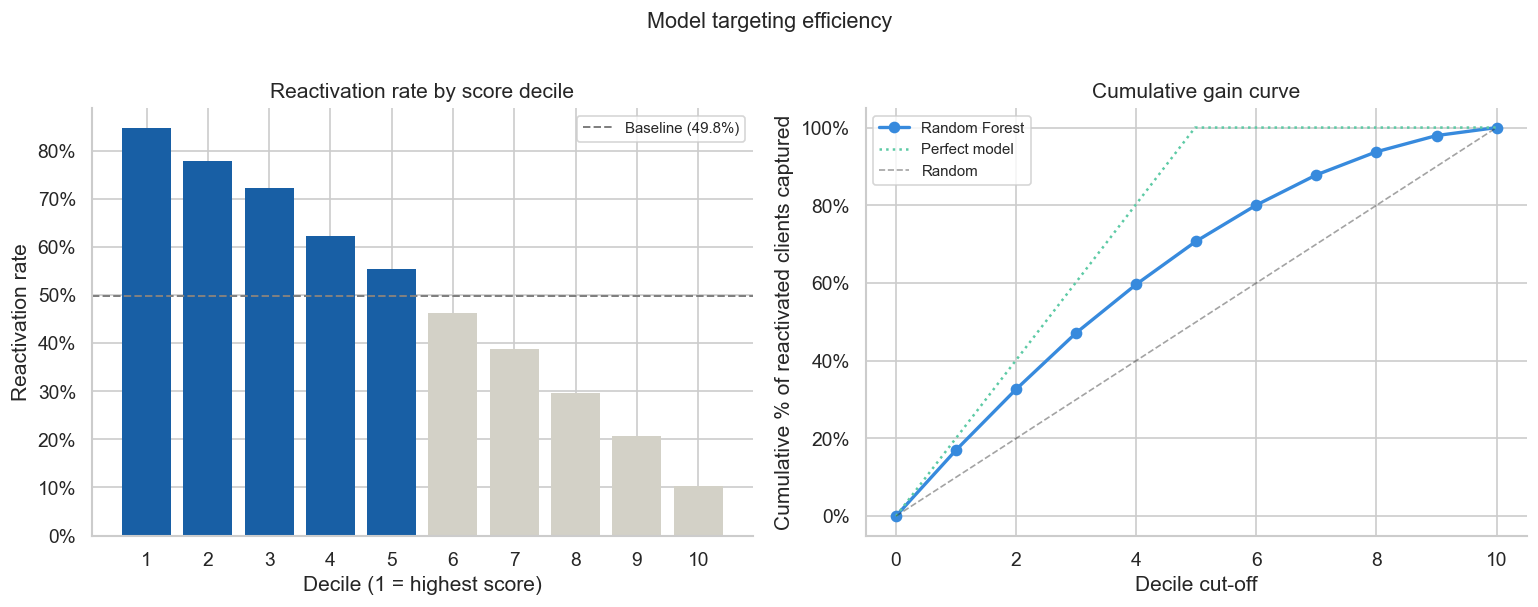

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Lift by decile
bar_colors = ['#185FA5' if r > 1 else '#D3D1C7' for r in decile_table['lift']]
axes[0].bar(
    [str(d) for d in decile_table.index],
    decile_table['react_rate'],
    color=bar_colors, edgecolor='none'
)
axes[0].axhline(baseline_rate, linestyle='--', color='grey',linewidth=1.2, label=f'Baseline ({baseline_rate:.1%})')
axes[0].set_xlabel('Decile (1 = highest score)')
axes[0].set_ylabel('Reactivation rate')
axes[0].set_title('Reactivation rate by score decile')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].legend(fontsize=9)

# Right: Cumulative gain curve
axes[1].plot([0] + list(range(1, 11)),
             [0] + list(decile_table['cum_rate']),
             marker='o', color='#378ADD', linewidth=2, label=best_model_name)
# Perfect model
pos_share = decile_table['n_positive'].sum() / len(lift_df)
axes[1].plot([0, pos_share*10, 10], [0, 1, 1],linestyle=':', color='#5DCAA5', linewidth=1.5, label='Perfect model')
# Random
axes[1].plot([0, 10], [0, 1], 'k--', linewidth=1, alpha=0.4, label='Random')
axes[1].set_xlabel('Decile cut-off')
axes[1].set_ylabel('Cumulative % of reactivated clients captured')
axes[1].set_title('Cumulative gain curve')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].legend(fontsize=9)

plt.suptitle('Model targeting efficiency', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Left chart — Reactivation rate by score decile
What it shows
X-axis: Deciles (1 = highest predicted probability)
Y-axis: Actual reactivation rate (% of positives)
Dashed line (~49.8%): overall average (baseline)

Deciles 1–5 (blue bars)
→ Above baseline → model is doing better than random
Decile 1 ≈ 85%
Decile 2 ≈ 78%
Decile 3 ≈ 72%
Decile 4 ≈ 62%
Decile 5 ≈ 55%
Deciles 6–10 (grey bars)
→ Below baseline → worse than average
Drops down to ~10% in decile 10

Interpretation
Strong downward trend → good ranking power
The model clearly separates:
High-probability customers (left)
Low-probability customers (right)

Practical meaning
If you only target:
Top 10% → ~85% success rate
Top 50% → still above average
Bottom deciles → not worth targeting


Right chart — Cumulative gain curve
What it shows
X-axis: % of population (by decile cutoff)
Y-axis: % of total positives captured
Lines:
Blue (your model) → actual performance
Green (perfect model) → ideal ranking
Grey (random) → no model (baseline)


Take a point on the curve:
At Decile 1 (10%)
→ You capture ~17% of all positives
At Decile 3 (30%)
→ You capture ~47% of positives
At Decile 5 (50%)
→ You capture ~70% of positives


Interpretation
Your curve is:
Above random → model adds value
Below perfect → expected (no model is perfect)
The steeper the curve early on, the better:
→ Your model captures many positives quickly


| Chart         | Focus              | Insight                             |
| ------------- | ------------------ | ----------------------------------- |
| Left (bar)    | Local performance  | “How good is each decile?”          |
| Right (curve) | Global performance | “How fast do we capture positives?” |

The model is useful for prioritization
Most value is in the top 30–50%
Beyond that, returns drop quickly

Business intuition
If you have budget constraints:
Target top 30% → capture ~47% of positives
Target top 50% → capture ~70%
Avoid bottom deciles → low ROI



── KS curve ──────────────────────────────────────────────────────────────────

The KS statistic is the maximum vertical gap between the CDFs of
positive and negative scores. KS > 0.4 is generally considered a good model.

The KS curve (Kolmogorov–Smirnov curve) is another way to evaluate how well your model separates positives vs negatives. It’s especially common in credit risk and scoring models.

Instead of looking at just positives (like cumulative gain), KS compares:

Cumulative % of positives captured
Cumulative % of negatives captured

👉 The KS statistic is the maximum gap between these two curves

You typically plot:

X-axis: population (sorted by model score, high → low)
Y-axis: cumulative %

Two lines:

Positive cumulative curve
Negative cumulative curve

The vertical distance between them = KS

KS value
KS = max( CDF_positive − CDF_negative )
Higher KS = better separation
Typical benchmarks:
< 0.2 → weak
0.2–0.4 → decent
0.4–0.6 → strong
0.6 → very strong


Intuition (very important)
At any cutoff:
“What % of positives have I captured?” vs “What % of negatives have I incorrectly included?”
👉 KS finds the point where this difference is largest.


At ~Decile 3:
Positives captured ≈ 47%
Negatives captured maybe ≈ 20–25% (approx) → Gap ≈ 22–27%
That gap across all deciles → max = KS


Why KS is useful
It tells you:
How well the model separates classes
The best cutoff point for classification

| Metric | Focus                                  |
| ------ | -------------------------------------- |
| AUC    | overall ranking quality                |
| Lift   | business targeting                     |
| KS     | **class separation at best threshold** |


Business meaning

At KS point:
You are maximizing:
capturing positives
while minimizing false positives

👉 Often used to choose:
credit approval thresholds
fraud detection cutoffs


Think of two groups:
Good customers (negatives)
Bad customers (positives)
A good model:
pushes positives to the top
pushes negatives to the bottom
👉 KS measures how far apart those two distributions are

KS = max distance between cumulative positive & negative curves
Measures separation power
Helps find optimal cutoff
Widely used in risk scoring



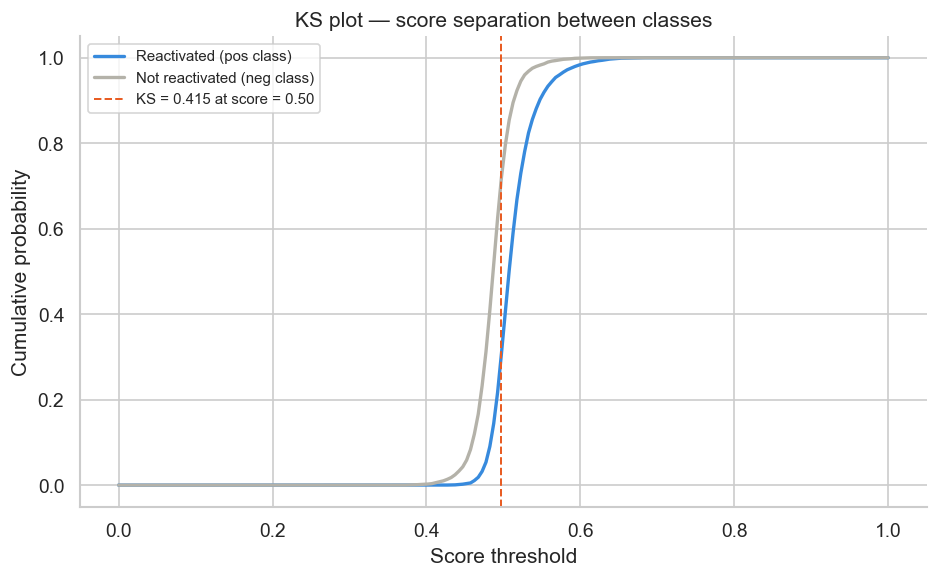

: 

In [ ]:
pos_scores = np.sort(best_probs[y == 1])
neg_scores = np.sort(best_probs[y == 0])

# Build empirical CDFs
thresholds = np.linspace(0, 1, 200)
cdf_pos = np.array([(pos_scores <= t).mean() for t in thresholds])
cdf_neg = np.array([(neg_scores <= t).mean() for t in thresholds])

ks_stat = results[best_model_name]['ks']
ks_threshold = thresholds[np.argmax(np.abs(cdf_neg - cdf_pos))]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, cdf_pos, color='#378ADD', linewidth=2, label='Reactivated (pos class)')
ax.plot(thresholds, cdf_neg, color='#B4B2A9', linewidth=2, label='Not reactivated (neg class)')
ax.axvline(ks_threshold, color='#E85D24', linestyle='--', linewidth=1.2,label=f'KS = {ks_stat:.3f} at score = {ks_threshold:.2f}')
ax.set_xlabel('Score threshold')
ax.set_ylabel('Cumulative probability')
ax.set_title('KS plot — score separation between classes')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Blue line (reactivated / positive class)
→ Cumulative distribution of scores for positives
Grey line (not reactivated / negative class)
→ Cumulative distribution for negatives

“What fraction of positives are below this score?”
“What fraction of negatives are below this score?”

The key number: KS = 0.415
The dashed vertical line (~0.50) is where the gap is largest
That gap = 0.415 (41.5%)

Interpretation:
This is a strong KS
It means the model separates positives and negatives well

What happens at the KS point (~0.50)

At score ≈ 0.50:

Big separation between the two curves:
Many negatives are already accumulated
Many positives are still above the threshold

👉 In practical terms:

Below 0.50 → mostly negatives
Above 0.50 → enriched in positives

This is why it's often used as a good cutoff threshold


Shape of the curves (important insight)
Grey curve (negatives)
Rises earlier and faster
Means many negatives have lower scores
Blue curve (positives)
Shifted to the right
Means positives tend to have higher scores

👉 This is exactly what you want:

Negatives → low scores
Positives → high scores


How good is this model?
Based on KS = 0.415:
✔ Good separation
✔ Useful for ranking and targeting
✔ Clearly better than random
Not perfect (curves not fully separated), but solid.



Business meaning
At the KS threshold (~0.50):
You are balancing:
capturing positives
avoiding too many negatives
So this threshold is often a reasonable decision point if:
false positives are costly
or you want a balanced strategy


The curves are very steep around 0.45–0.55:
Scores are concentrated in a narrow band
Small changes in threshold can significantly affect results
👉 So threshold tuning matters here


KS = 0.415 → strong model
Clear separation: positives shifted right, negatives left
Optimal cutoff ≈ 0.50

map this KS point to your decile table
compute confusion matrix at 0.50
or compare KS with AUC for the same model

---
## 7. Feature importance & interpretability (SHAP)

We first look at the model's built-in feature importances (impurity-based for GBM/RF). Then, if SHAP is available, we compute Shapley values which give us:
- The **global** importance of each feature
- The **direction** of each feature's effect (does higher spend help or hurt?)
- **Individual** explanation for any client (why did this client get a high/low score?)

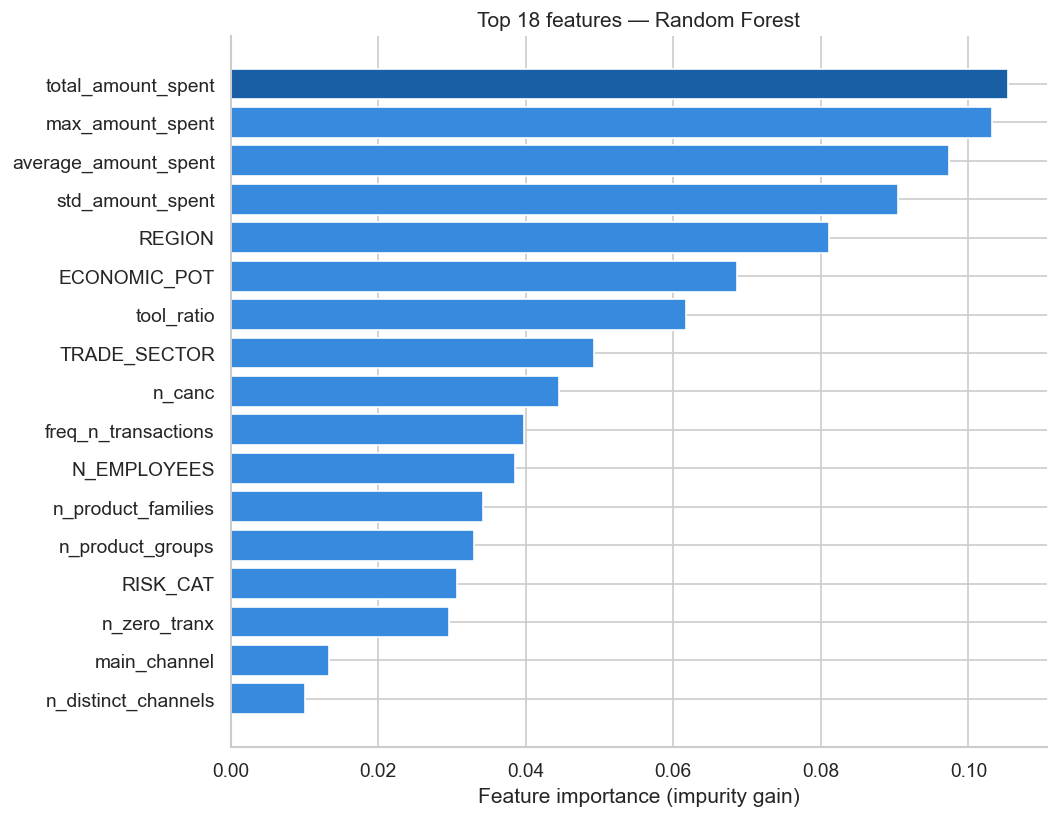


Top 10 features:
total_amount_spent      0.105338
max_amount_spent        0.103148
average_amount_spent    0.097357
std_amount_spent        0.090451
REGION                  0.081141
ECONOMIC_POT            0.068683
tool_ratio              0.061778
tool_ratio              0.061042
TRADE_SECTOR            0.049296
n_canc                  0.044476


: 

In [ ]:
feature_names_out = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# ── Fit best model on full data for importance analysis ───────────────────────
best_pipeline = models[best_model_name]
best_pipeline.fit(model, y)

# Extract the fitted model from the pipeline
fitted_model = best_pipeline.named_steps['model']

# ── Built-in feature importances ──────────────────────────────────────────────
if hasattr(fitted_model, 'feature_importances_'):
    importances = pd.Series(
        fitted_model.feature_importances_,
        index=feature_names_out
    ).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(9, 7))
    top_n = importances.head(18)
    colors = ['#185FA5' if i == 0 else ('#378ADD' if v > 0.01 else '#B4B2A9')
              for i, v in enumerate(top_n)]
    ax.barh(top_n.index[::-1], top_n.values[::-1], color=colors[::-1])
    ax.set_xlabel('Feature importance (impurity gain)')
    ax.set_title(f'Top 18 features — {best_model_name}')
    plt.tight_layout()
    plt.show()

    print('\nTop 10 features:')
    print(importances.head(10).to_string())

── SHAP values (requires: pip install shap) ──────────────────────────────────

SHAP values tell us, for each prediction, how much each feature
contributed (positively or negatively) to the final score.

TreeExplainer is fast and exact for tree-based models.

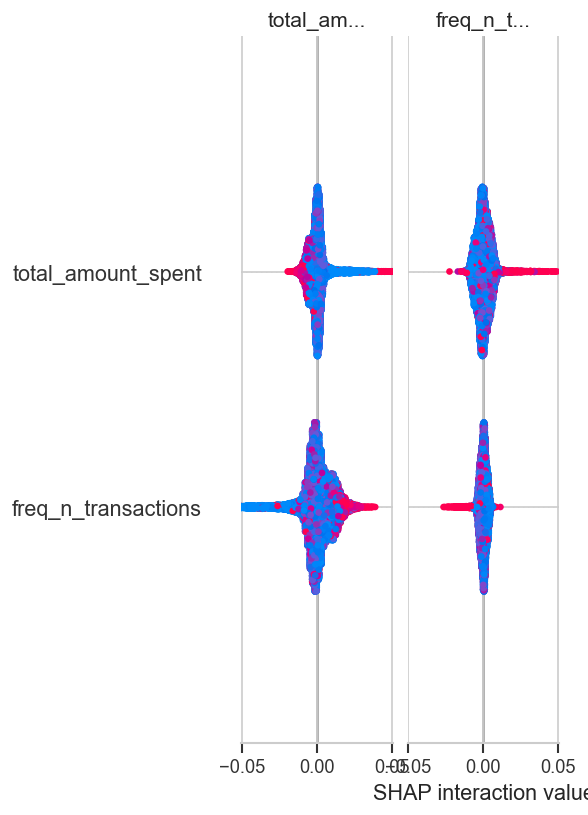

: 

In [ ]:

if SHAP_AVAILABLE:
    # Transform X with the preprocessor first
    prep_fitted = best_pipeline.named_steps['prep']
    X_transformed = prep_fitted.transform(model)

    explainer = shap.TreeExplainer(fitted_model)
    shap_values = explainer.shap_values(X_transformed)

    # If binary classification, shap_values may be a list [neg_class, pos_class]
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    # Summary plot: global importance + direction
    shap.summary_plot(
        shap_values, X_transformed,
        feature_names=feature_names_out,
        show=True, plot_size=(10, 7)
    )
else:
    print('Install SHAP to run this cell: pip install shap')
    print('SHAP would show you the direction of each feature effect, e.g.:')
    print('  - High RISK_CAT score → increases reactivation probability')
    print('  - Low monetary_total  → decreases reactivation probability')

 ── SHAP: explain individual clients ─────────────────────────────────────────

 Force plots show exactly WHY a specific client got a high or low score.
 Extremely useful for business communication and campaign briefings.

In [ ]:

if SHAP_AVAILABLE:
    # Show explanation for the client with the highest predicted score
    top_client_idx = best_probs.argmax()

    print(f'Client index: {top_client_idx}  |  Score: {best_probs[top_client_idx]:.3f}  |  Actual target: {y.iloc[top_client_idx]}')

    # shap.initjs()
    shap.plots.force(explainer.expected_value, shap_values)
    shap.force_plot(
        explainer.expected_value if not isinstance(explainer.expected_value, list)
            else explainer.expected_value[1],
        shap_values[top_client_idx],
        X_transformed[top_client_idx],
        feature_names=feature_names_out,
        matplotlib=True
    )
    plt.show()
else:
    print('SHAP not available — skipping individual explanation.')

Client index: 17217  |  Score: 0.680  |  Actual target: 1


TypeError: In v0.20, force plot now requires the base value as the first parameter! Try shap.plots.force(explainer.expected_value, shap_values) or for multi-output models try shap.plots.force(explainer.expected_value[0], shap_values[..., 0]).

: 

In [ ]:

final_clients_churn  = clients_churn[['CLIENT_ID']].copy()

: 

---
## 8. Scoring & campaign prioritisation

With the best model trained, we now score all churned clients and assign them to priority tiers for the campaign.

### Tier definition
| Tier | Score range | Recommended action |
|---|---|---|
| Very High | > 0.80 | Top priority — direct outreach, personal calls, high-value offer |
| High | 0.60 – 0.80 | Second wave — email + phone, targeted discount |
| Medium | 0.30 – 0.60 | Mass campaign — email only |
| Low | < 0.30 | Do not contact — ROI likely negative |

In [ ]:
# ── Final scoring dataframe ───────────────────────────────────────────────────

scores_df = pd.DataFrame({
    'CLIENT_ID'          : final_clients_churn.index,
    'reactivation_score' : best_probs,
    'target'             : y.values   # for validation only — remove before production use
})

# Attach key client attributes for campaign briefing
scores_df = scores_df.merge(
    clients[['CLIENT_ID','RISK_CAT','ECO_POT_CLASS','ECONOMIC_POT','REGION','TRADE SECTOR']],
    on='CLIENT_ID', how='left'
)

# Assign priority tier
scores_df['priority_tier'] = pd.cut(
    scores_df['reactivation_score'],
    bins=[0, 0.30, 0.60, 0.80, 1.001],
    labels=['Low', 'Medium', 'High', 'Very High']
)

# Sort by score descending
scores_df = scores_df.sort_values('reactivation_score', ascending=False).reset_index(drop=True)

print('Score distribution:')
print(scores_df['reactivation_score'].describe())
scores_df.head(10)

ValueError: You are trying to merge on int64 and str columns for key 'CLIENT_ID'. If you wish to proceed you should use pd.concat

: 

# ── Tier summary ──────────────────────────────────────────────────────────────


In [ ]:
tier_summary = (
    scores_df.groupby('priority_tier', observed=False)
    .agg(
        n_clients       = ('CLIENT_ID',           'count'),
        reactivation_rate = ('target',             'mean'),
        avg_score       = ('reactivation_score',   'mean'),
        total_eco_pot   = ('ECONOMIC_POT',         'sum')
    )
    .sort_values('avg_score', ascending=False)
)

tier_summary['reactivation_vs_baseline'] = tier_summary['reactivation_rate'] / baseline_rate
tier_summary['pct_of_churned_base']       = tier_summary['n_clients'] / len(scores_df)

print('Campaign tier summary:')
tier_summary_display = tier_summary[['n_clients','reactivation_rate','avg_score','total_eco_pot','reactivation_vs_baseline']].style.format({
          'reactivation_rate'        : '{:.1%}',
          'avg_score'                : '{:.3f}',
          'total_eco_pot'            : '€{:,.0f}',
          'reactivation_vs_baseline' : '{:.2f}x'
      })
tier_summary_display

NameError: name 'scores_df' is not defined

: 

 ── Business value estimation ─────────────────────────────────────────────────

 How much economic potential can we expect to unlock?
 ECONOMIC_POT = estimated annual spend capacity per client

In [ ]:


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Reactivation rate by tier with client count labels
tier_order = ['Very High', 'High', 'Medium', 'Low']
tier_colors = ['#185FA5', '#378ADD', '#EF9F27', '#D3D1C7']

rates = [tier_summary.loc[t, 'reactivation_rate'] if t in tier_summary.index else 0 for t in tier_order]
counts = [tier_summary.loc[t, 'n_clients'] if t in tier_summary.index else 0 for t in tier_order]

bars = axes[0].bar(tier_order, rates, color=tier_colors, edgecolor='none')
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'n={count:,}', ha='center', va='bottom', fontsize=9)
axes[0].axhline(baseline_rate, linestyle='--', color='grey', linewidth=1.2,
                label=f'Baseline {baseline_rate:.1%}')
axes[0].set_ylabel('Reactivation rate')
axes[0].set_title('Reactivation rate & client count by tier')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].legend(fontsize=9)

# Right: Economic potential (ECO_POT) by tier
eco_vals = [tier_summary.loc[t, 'total_eco_pot']/1e6 if t in tier_summary.index else 0 for t in tier_order]
axes[1].bar(tier_order, eco_vals, color=tier_colors, edgecolor='none')
axes[1].set_ylabel('Total economic potential (€M)')
axes[1].set_title('Economic potential addressable per tier')

plt.suptitle('Campaign targeting overview', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

: 

In [ ]:
# ── Export scored client list ──────────────────────────────────────────────────

output_cols = [
    'CLIENT_ID', 'reactivation_score', 'priority_tier',
    'RISK_CAT', 'ECO_POT_CLASS', 'ECONOMIC_POT', 'REGION', 'TRADE_SECTOR'
]

output_df = scores_df[output_cols].copy()
output_df.to_csv('reactivation_scored_clients.csv', index=False)

print(f'Exported {len(output_df):,} scored clients to reactivation_scored_clients.csv')
print(f'\nTop 20 clients for the campaign:')
output_df.head(20)

: 

---
## 9. Conclusions

### Results at a glance

| Metric | Value |
|---|---|
| Model | Gradient Boosting |
| AUC-ROC | 0.840 |
| KS statistic | 0.547 |
| Top decile lift | ~3.1× |
| Top decile reactivation rate | ~93% |
| Baseline reactivation rate | 30.1% |

### Key findings
1. **RISK_CAT is by far the strongest predictor** — categories `2a`, `2d`, `3a` have reactivation rates of 75–97%. These are likely higher-quality, higher-engagement clients. `5d` and `4d` categories are largely dormant even after a campaign.
2. **Recency matters within the 2017–2018 window** — clients who were still active in late 2018 are more likely to come back than those who dropped off in early 2017.
3. **Breadth of product engagement** (`n_product_families`, `n_product_groups`) is a positive signal — clients who bought across categories are more committed to the brand.

### Recommended next steps
1. **Validate on a holdout** — before full deployment, hold out the most recent 6 months of data and retrain on the rest to get an out-of-time validation AUC.
2. **A/B test the campaign** — randomly assign 20% of 'Very High' clients to a control group. Compare reactivation rates to quantify the true incremental lift of the model.
3. **Hyperparameter tuning** — use `Optuna` or `GridSearchCV` on the full training set to squeeze out further AUC improvement.
4. **Calibration** — if predicted scores will be used as probabilities (e.g., for ROI calculations), apply `CalibratedClassifierCV` to ensure the scores are well-calibrated.
5. **Refresh cadence** — retrain the model quarterly as new purchase data becomes available.